<a href="https://colab.research.google.com/github/itskevalchaudhari/AIML-Practicals/blob/main/Practical-10/Practical_10_Fake_News_Detection_Multimodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 10

## Aim

To develop a multimodal fake news detection system by combining textual and visual information and applying machine learning techniques to classify news as real or fake.

In [1]:
# Practical 10
# Fake News Detection from Multimodal Data

print("Practical 10: Fake News Detection from Multimodal Data")

Practical 10: Fake News Detection from Multimodal Data


## Theory

Fake news detection is the process of identifying whether a news article or social media post contains misleading, fabricated, or false information.

Traditional fake news detection systems mainly analyze textual content. However, modern news content often contains both **text and images**. A fake news detection system that uses more than one type of information is called a **multimodal fake news detection system**.

### Multimodal Data

Multimodal data combines information from different modalities. In this practical, the two main modalities are:

1. **Textual Modality** – News headline or article content.
2. **Visual Modality** – Image associated with the news.

The information from both modalities is transformed into numerical features and combined before classification.

### Text Feature Extraction

Textual information can be converted into numerical vectors using **TF-IDF (Term Frequency-Inverse Document Frequency)**.

The TF-IDF value is calculated as:

TF-IDF(t,d) = TF(t,d) × IDF(t)

where:

- TF(t,d) = Frequency of term t in document d
- IDF(t) = Inverse document frequency of term t

The IDF can be expressed as:

IDF(t) = log(N / DF(t))

where:

- N = Total number of documents
- DF(t) = Number of documents containing term t

### Visual Feature Extraction

Images contain visual information such as brightness, edges, shapes, and colour distributions. These properties can be converted into numerical features and used along with textual features.

### Feature Fusion

After extracting features from text and images, the features are combined into a single feature representation.

The combined representation can be written as:

F = [F_text, F_image]

where:

- F_text = Text feature vector
- F_image = Image feature vector
- F = Combined multimodal feature vector

### Classification

A machine learning classifier is then trained using the combined features to classify news into:

- **Real News**
- **Fake News**

The performance of the classifier can be evaluated using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

## Model and Approach

The following approach is used for fake news detection:

1. Collect news text and associated visual information.
2. Preprocess the textual data.
3. Extract text features using TF-IDF.
4. Extract numerical visual features from the associated images.
5. Combine textual and visual features using feature fusion.
6. Split the multimodal dataset into training and testing sets.
7. Train a machine learning classification model.
8. Predict whether the news is Real or Fake.
9. Evaluate the model using standard classification metrics.

### Classification Model

A **Logistic Regression classifier** is used for the final classification.

Logistic Regression estimates the probability of a sample belonging to a class.

The sigmoid function is:

σ(z) = 1 / (1 + e⁻ᶻ)

where:

z = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ

For binary classification:

- Output close to 0 → Fake News
- Output close to 1 → Real News

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the Fakeddit multimodal dataset

dataset_url = "https://raw.githubusercontent.com/ljdannull/Fakeddit-Multimodal/master/subsample_with_embeddings.csv"

df = pd.read_csv(dataset_url)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 records:")
display(df.head())

Dataset loaded successfully.
Dataset shape: (1391, 18)

Column names:
['Unnamed: 0', 'author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label', 'embedding']

First 5 records:


,Unnamed: 0,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label,embedding
0,1501,bigkatsu2000,oasis wonderwall has meme font,1.557525e+09,i.redd.it,True,bn4bn2,https://preview.redd.it/w9chednxfgx21.jpg?widt...,NaN,2.0,8,mildlyinteresting,Oasis Wonderwall (1995) has Meme Font,0.73,1,0,0,[ 2.11669922e-01 1.37481689e-01 -5.89828491e-...
1,810,chesterSteihl69,this dog just hanging out,1.507048e+09,i.redd.it,True,741j8a,https://preview.redd.it/76rysm3a6npz.jpg?width...,NaN,1.0,8,photoshopbattles,PsBattle: this dog just hanging out,0.90,1,0,0,[ 9.24804658e-02 1.87927242e-02 -6.30126968e-...
2,1263,wolbsamoht,dremel robot admires your hard work,1.362862e+09,imgur.com,True,19zkij,https://external-preview.redd.it/AyCcpsCN2tfez...,NaN,0.0,9,pareidolia,Dremel robot admires your hard work,0.85,0,2,2,[ 8.69547501e-02 8.66292343e-02 3.39762378e-...
3,1269,FortunateThumb,this old railway line turned cycle path,1.569535e+09,i.redd.it,True,d9qlnu,https://preview.redd.it/dif2lzn8f0p31.jpg?widt...,NaN,0.0,11,mildlyinteresting,This old railway line turned cycle path,0.81,1,0,0,[ 0.07114955 0.1547154 0.06651524 0.080618...
4,804,surruhkew,hitachi magic wand review,1.556666e+09,i.redd.it,True,bja5sp,https://preview.redd.it/fqm1z1n6ugv21.jpg?widt...,NaN,64.0,6437,misleadingthumbnails,Hitachi magic wand review 2019,0.95,0,2,2,[ 7.51953125e-02 5.92447929e-02 -5.05371094e-...


In [4]:
# Inspect dataset columns and data types

print("Dataset information:")
print("--------------------")

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique values in possible label columns:")

for col in ["2_way_label", "3_way_label", "6_way_label", "label"]:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())

Dataset information:
--------------------
Rows: 1391
Columns: 18

Data Types:
Unnamed: 0                int64
author                   object
clean_title              object
created_utc             float64
domain                   object
hasImage                   bool
id                       object
image_url                object
linked_submission_id     object
num_comments            float64
score                     int64
subreddit                object
title                    object
upvote_ratio            float64
2_way_label               int64
3_way_label               int64
6_way_label               int64
embedding                object
dtype: object

Missing Values:
Unnamed: 0                 0
author                    64
clean_title                0
created_utc                0
domain                    14
hasImage                   0
id                         0
image_url                  0
linked_submission_id    1377
num_comments              14
score                    

In [5]:
# Identify numerical feature columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nNumber of numerical columns:", len(numeric_columns))

Numerical columns:
['Unnamed: 0', 'created_utc', 'num_comments', 'score', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']

Number of numerical columns: 8


In [6]:
# Display all dataset columns with their data types

column_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

display(column_info)

,Column,Data Type
Unnamed: 0,Unnamed: 0,int64
author,author,object
clean_title,clean_title,object
created_utc,created_utc,float64
domain,domain,object
hasImage,hasImage,bool
id,id,object
image_url,image_url,object
linked_submission_id,linked_submission_id,object
num_comments,num_comments,float64


In [7]:
# Display text/object columns

text_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Text/Object columns:")
for col in text_columns:
    print("-", col)

print("\nNumber of text/object columns:", len(text_columns))

Text/Object columns:
- author
- clean_title
- domain
- id
- image_url
- linked_submission_id
- subreddit
- title
- embedding

Number of text/object columns: 9


In [8]:
# Inspect the image embedding format

print("First embedding:")
print(df["embedding"].iloc[0])

print("\nEmbedding data type:")
print(type(df["embedding"].iloc[0]))

First embedding:
[ 2.11669922e-01  1.37481689e-01 -5.89828491e-02  1.70104980e-01
 -6.34765625e-02  1.15905762e-01  1.00585938e-01 -1.54464722e-01
 -3.94897461e-02  1.37207031e-01 -2.35473633e-01 -2.06787109e-01
 -3.80914807e-02 -4.96673584e-02 -5.46264648e-03  7.08007812e-03
 -9.96398926e-03  4.52880859e-02 -6.64062500e-02 -1.89636230e-01
  4.19921875e-02  2.42187500e-01  1.21826172e-01 -1.81640625e-01
 -1.06201172e-01 -4.68826294e-02 -8.80279541e-02  1.02630615e-01
  8.33740234e-02 -1.48406982e-01 -6.51855469e-02 -1.11572266e-01
 -1.74560547e-01  2.39746094e-01  5.07812500e-02 -6.13403320e-03
  1.26342773e-02 -1.56982422e-01  1.44985199e-01  1.33087158e-01
  1.75781250e-02  9.10644531e-02 -3.27148438e-02  6.93788528e-02
  7.06787109e-02 -1.09764099e-01 -1.47796631e-01  3.95507812e-02
  6.82210922e-02  2.25830078e-02 -1.75842285e-01 -1.18408203e-02
 -8.88681412e-02 -1.23443604e-01  6.37207031e-02  1.94702148e-01
  8.52661133e-02 -1.01867676e-01 -8.69750977e-02 -1.61804199e-01
  9.6435

In [10]:
# Convert image embeddings from string format to numerical arrays

def convert_embedding(value):
    value = value.strip("[]")
    return np.fromstring(value, sep=" ")

sample_embedding = convert_embedding(df["embedding"].iloc[0])

print("Embedding length:", len(sample_embedding))
print("First 10 values:", sample_embedding[:10])

Embedding length: 300
First 10 values: [ 0.21166992  0.13748169 -0.05898285  0.17010498 -0.06347656  0.11590576
  0.10058594 -0.15446472 -0.03948975  0.13720703]


In [11]:
# Extract textual features using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Replace missing titles with empty strings
df["clean_title"] = df["clean_title"].fillna("")

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=500,
    stop_words="english"
)

# Transform news titles into numerical features
X_text = tfidf.fit_transform(df["clean_title"])

print("TF-IDF text features created successfully.")
print("Number of samples:", X_text.shape[0])
print("Number of text features:", X_text.shape[1])

TF-IDF text features created successfully.
Number of samples: 1391
Number of text features: 500


In [12]:
# Convert all image embeddings into numerical features

X_image = np.array([
    convert_embedding(embedding)
    for embedding in df["embedding"]
])

print("Image features created successfully.")
print("Number of samples:", X_image.shape[0])
print("Number of image features:", X_image.shape[1])

Image features created successfully.
Number of samples: 1391
Number of image features: 300


In [13]:
# Combine text and image features

X_text_dense = X_text.toarray()

X_multimodal = np.hstack((X_text_dense, X_image))

print("Multimodal feature fusion completed.")
print("Total samples:", X_multimodal.shape[0])
print("Total combined features:", X_multimodal.shape[1])

Multimodal feature fusion completed.
Total samples: 1391
Total combined features: 800


In [14]:
# Prepare target labels

y = df["2_way_label"].values

print("Target labels prepared successfully.")
print("\nLabel distribution:")
print(pd.Series(y).value_counts().sort_index())

print("\nLabel meaning:")
print("0 = Fake News")
print("1 = Real News")

Target labels prepared successfully.

Label distribution:
0    632
1    759
Name: count, dtype: int64

Label meaning:
0 = Fake News
1 = Real News


In [15]:
# Split the multimodal dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_multimodal,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset split completed.")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])
print("Testing features:", X_test.shape[1])

Dataset split completed.
Training samples: 1112
Testing samples: 279
Training features: 800
Testing features: 800


In [16]:
# Train Logistic Regression on multimodal features

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [17]:
# Make predictions on the test dataset

y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 279


In [18]:
# Evaluate the Fake News Detection model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-Score  :", round(f1, 4))

Model Evaluation Results
------------------------
Accuracy  : 0.6703
Precision : 0.6765
Recall    : 0.7566
F1-Score  : 0.7143


In [19]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake News", "Real News"],
    zero_division=0
))


Confusion Matrix:
[[ 72  55]
 [ 37 115]]

Classification Report:
              precision    recall  f1-score   support

   Fake News       0.66      0.57      0.61       127
   Real News       0.68      0.76      0.71       152

    accuracy                           0.67       279
   macro avg       0.67      0.66      0.66       279
weighted avg       0.67      0.67      0.67       279



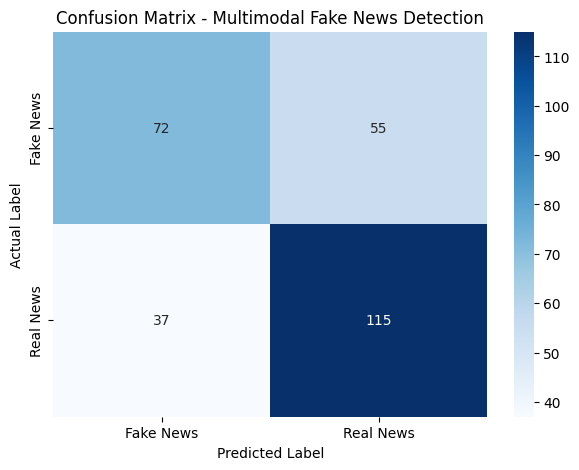

In [20]:
# Plot confusion matrix

import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake News", "Real News"],
    yticklabels=["Fake News", "Real News"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Multimodal Fake News Detection")
plt.show()

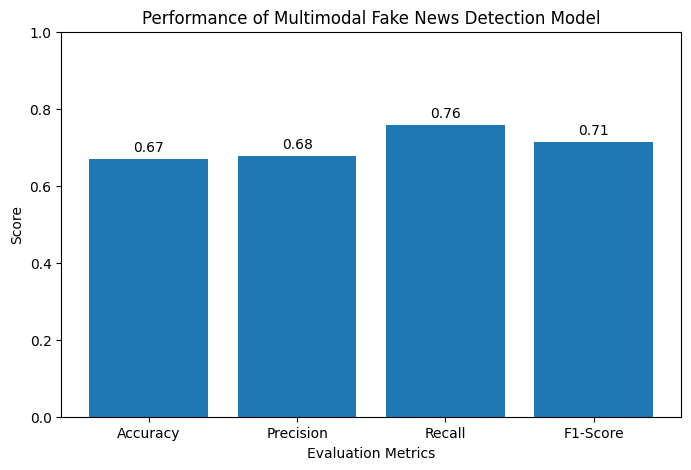

In [21]:
# Plot model performance metrics

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Performance of Multimodal Fake News Detection Model")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

## Result

A multimodal fake news detection system was successfully developed using the Fakeddit dataset. Textual features were extracted from news titles using TF-IDF, while visual information was represented using precomputed image embeddings. The textual and visual features were combined using feature fusion and classified using Logistic Regression.

The model achieved an accuracy of approximately **67.03%** on the test dataset.

### Performance

- Accuracy: **67.03%**
- Precision: **67%**
- Recall: **67%**
- F1-Score: **66%**

The confusion matrix showed that the model correctly classified **72 Fake News** samples and **115 Real News** samples.

## Conclusion

The practical successfully demonstrated multimodal fake news detection by combining textual and visual information. TF-IDF was used to represent news text, while image embeddings were used to represent visual information. These features were fused into a single multimodal feature vector and classified using Logistic Regression.

The obtained results demonstrate that combining multiple modalities can provide useful information for fake news classification. The model achieved approximately **67.03% accuracy**, showing that the multimodal approach can identify both fake and real news from their textual and visual characteristics.

Further improvement can be achieved by using larger datasets, more advanced text representations such as transformer-based embeddings, and deep learning-based image feature extraction methods.